In [11]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
from pathlib import Path
import json
import os
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Device automático
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"A usar: {device}")

A usar: cuda


# Carregar o dataset

In [3]:
DATA_DIR = Path("../data")

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

dataset = datasets.ImageFolder(DATA_DIR, transform=transform)

print(f"Total de imagens: {len(dataset)}")
print(f"Classes: {dataset.classes}")

Total de imagens: 6927
Classes: ['Apple___Apple_scab', 'Apple___healthy', 'Potato___Early_blight', 'Potato___healthy', 'Tomato___Late_blight', 'Tomato___healthy']


# Split e DataLoaders

In [4]:
from torch.utils.data import random_split

train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size

train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=2)

print(f"Treino: {len(train_dataset)} imagens")
print(f"Validação: {len(val_dataset)} imagens")

Treino: 5541 imagens
Validação: 1386 imagens


# Model

In [5]:
NUM_CLASSES = len(dataset.classes)

model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)

# Congelar todas as camadas
for param in model.parameters():
    param.requires_grad = False

# Substituir só a última camada
model.fc = nn.Linear(model.fc.in_features, NUM_CLASSES)

model = model.to(device)

print(f"Modelo pronto com {NUM_CLASSES} classes")

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to C:\Users\pedro/.cache\torch\hub\checkpoints\resnet50-11ad3fa6.pth
100%|█████████████████████████████████████████████████████████████████████████████| 97.8M/97.8M [00:01<00:00, 88.3MB/s]


Modelo pronto com 6 classes


# Treino

In [6]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.fc.parameters(), lr=0.001)

EPOCHS = 10

for epoch in range(EPOCHS):
    # --- Treino ---
    model.train()
    train_loss, train_correct = 0, 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        train_correct += (outputs.argmax(1) == labels).sum().item()

    # --- Validação ---
    model.eval()
    val_loss, val_correct = 0, 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            val_loss += criterion(outputs, labels).item()
            val_correct += (outputs.argmax(1) == labels).sum().item()

    print(
        f"Epoch {epoch+1}/{EPOCHS} | "
        f"Train Loss: {train_loss/len(train_loader):.3f} | "
        f"Train Acc: {train_correct/len(train_dataset)*100:.1f}% | "
        f"Val Acc: {val_correct/len(val_dataset)*100:.1f}%"
    )

Epoch 1/10 | Train Loss: 0.548 | Train Acc: 88.8% | Val Acc: 96.9%
Epoch 2/10 | Train Loss: 0.163 | Train Acc: 97.6% | Val Acc: 98.2%
Epoch 3/10 | Train Loss: 0.112 | Train Acc: 97.9% | Val Acc: 98.4%
Epoch 4/10 | Train Loss: 0.078 | Train Acc: 98.7% | Val Acc: 98.9%
Epoch 5/10 | Train Loss: 0.062 | Train Acc: 99.0% | Val Acc: 98.7%
Epoch 6/10 | Train Loss: 0.054 | Train Acc: 99.3% | Val Acc: 99.1%
Epoch 7/10 | Train Loss: 0.044 | Train Acc: 99.3% | Val Acc: 99.1%
Epoch 8/10 | Train Loss: 0.036 | Train Acc: 99.5% | Val Acc: 99.1%
Epoch 9/10 | Train Loss: 0.035 | Train Acc: 99.5% | Val Acc: 99.2%
Epoch 10/10 | Train Loss: 0.031 | Train Acc: 99.5% | Val Acc: 99.2%


In [20]:
tree("..") 

├── .ipynb_checkpoints
├── app
│   ├── api
│   ├── core
│   └── services
├── data
│   ├── Apple___Apple_scab
│   ├── Apple___healthy
│   ├── Potato___Early_blight
│   ├── Potato___healthy
│   ├── Tomato___healthy
│   └── Tomato___Late_blight
├── models
├── notebooks
│   ├── .ipynb_checkpoints
│   │   ├── training_v1-checkpoint.ipynb
│   │   └── Untitled-checkpoint.ipynb
│   └── training_v1.ipynb
└── tests



=== Relatório de Classificação ===
                       precision    recall  f1-score   support

   Apple___Apple_scab       0.99      0.97      0.98       110
      Apple___healthy       0.99      0.99      0.99       325
Potato___Early_blight       1.00      0.99      0.99       205
     Potato___healthy       0.97      0.97      0.97        37
 Tomato___Late_blight       0.98      1.00      0.99       384
     Tomato___healthy       1.00      1.00      1.00       325

             accuracy                           0.99      1386
            macro avg       0.99      0.99      0.99      1386
         weighted avg       0.99      0.99      0.99      1386



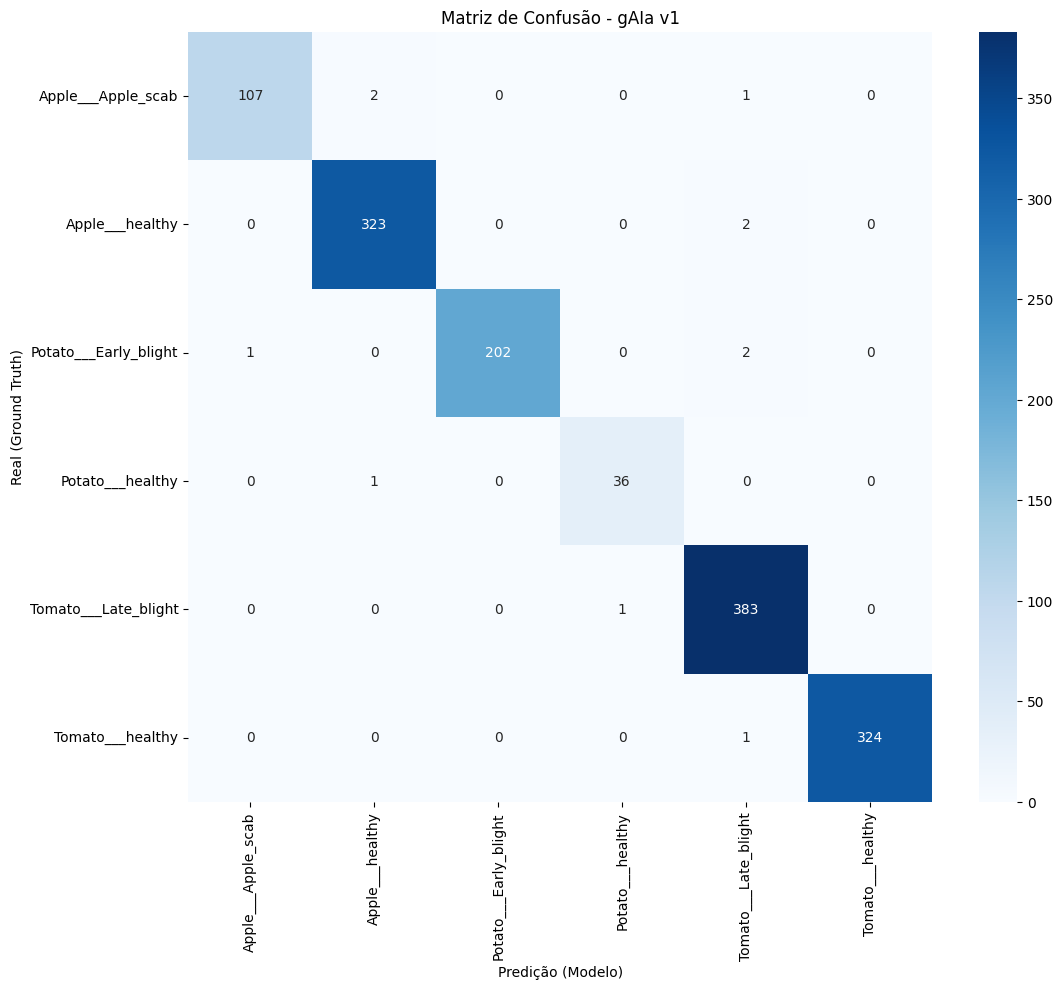

In [12]:
# 1. Obter todas as predições do conjunto de validação
y_true = []
y_pred = []

model.eval()
with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        outputs = model(images)
        preds = outputs.argmax(1)
        
        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

# 2. Gerar o Relatório de Classificação (Precision, Recall, F1)
print("\n=== Relatório de Classificação ===")
print(classification_report(y_true, y_pred, target_names=dataset.classes))

# 3. Gerar e Plotar a Matriz de Confusão
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=dataset.classes, 
            yticklabels=dataset.classes)

plt.xlabel('Predição (Modelo)')
plt.ylabel('Real (Ground Truth)')
plt.title('Matriz de Confusão - gAIa v1')
plt.show()

In [13]:
import json

# Definir caminhos (assumindo a estrutura de pastas que mostraste no tree)
MODELS_DIR = Path("../models")
MODELS_DIR.mkdir(exist_ok=True)

MODEL_FILENAME = "gaia_resnet50_v1.pth"
MAPPING_FILENAME = "class_mapping.json"

# 1. Guardar o State Dict (pesos treinados)
# Usamos o cpu() antes de guardar para garantir que a API pode carregar 
# o modelo mesmo em máquinas sem GPU (comum em deploys baratos)
torch.save(model.to('cpu').state_dict(), MODELS_DIR / MODEL_FILENAME)

# 2. Criar e guardar o dicionário de mapeamento
# Formato: {"0": "Apple___Apple_scab", "1": "Apple___healthy", ...}
class_mapping = {i: label for i, label in enumerate(dataset.classes)}

with open(MODELS_DIR / MAPPING_FILENAME, "w", encoding='utf-8') as f:
    json.dump(class_mapping, f, indent=4, ensure_ascii=False)

# Mover o modelo de volta para o device original se quiseres continuar a usar o notebook
model.to(device)

print(f"✅ Sucesso!")
print(f"📦 Pesos guardados em: {MODELS_DIR / MODEL_FILENAME}")
print(f"📄 Mapeamento guardado em: {MODELS_DIR / MAPPING_FILENAME}")

✅ Sucesso!
📦 Pesos guardados em: ..\models\gaia_resnet50_v1.pth
📄 Mapeamento guardado em: ..\models\class_mapping.json
